# <font color="steelblue">Métodos de escalado multidimensional (MDS)</font>

**Material desarrollado por los [equipos de trabajo de IA4LEGOS](https://ia4legos.umh.es/)**


**Fecha última edición**: 03/06/2026

**Licencia**: <small><a rel="license" href="http://creativecommons.org/licenses/by-sa/4.0/"><img alt="Creative Commons License" style="border-width:0" src="https://i.creativecommons.org/l/by-sa/4.0/88x31.png" /></a><br /></small>

No olvides hacer una copia si deseas utilizarlo. Al usar estos contenidos, aceptas nuestros términos de uso y nuestra política de privacidad.


In [1]:
# @title Cargar configuración del cuaderno
!pip install gdown
!pip install --upgrade kagglehub
!pip install lightgbm xgboost
!pip install ucimlrepo

# Análisis numérico
import numpy as np
import pandas as pd
import math, random
import warnings
warnings.filterwarnings('ignore')

# Gráficos
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
sns.set_theme(style='whitegrid')
%config InlineBackend.figure_format = 'retina'

import os, zipfile, gdown, kagglehub

# Funciones del curso
from urllib.request import urlretrieve
for fichero in ['preprocesar.py', 'evaluar_clasificadores.py', 'pca_funciones.py', 'auto_ML.py']:
    urlretrieve(f'https://raw.githubusercontent.com/ia4legos/MachineLearning/refs/heads/main/{fichero}', fichero)
from preprocesar import *
from evaluar_clasificadores import *
from pca_funciones import *
from auto_ML import *


# <font color="steelblue">1. Introducción al aprendizaje de variedades</font>

Ya vimos que el **análisis de componentes principales (PCA)** sirve para reducir la dimensión conservando las relaciones esenciales entre los puntos. Es flexible, rápido e interpretable, pero tiene una limitación de fondo: **es lineal**. Cuando la estructura de los datos está "curvada" (vive sobre una *variedad* no lineal incrustada en el espacio de alta dimensión), las direcciones rectas del PCA no la describen bien.

Para esos casos existe una familia de estimadores no supervisados llamada **aprendizaje de variedades** (*manifold learning*), que intenta describir los datos como una **variedad de baja dimensión** embebida en un espacio de alta dimensión. En estos dos cuadernos cerramos el bloque de reducción de la dimensión con tres de sus métodos clásicos: el **escalado multidimensional (MDS)**, la **incrustación localmente lineal (LLE)** y el **mapeado isométrico (Isomap)**.

Este primer cuaderno se centra en el **MDS**; el siguiente, en **LLE** e **Isomap**.

> **Idea unificadora:** mientras el PCA parte de la **matriz de características** $X$, el MDS parte de la **matriz de distancias/disimilitudes** entre puntos. Esto le da una ventaja decisiva: puede trabajar con **cualquier medida de disimilitud** (no solo la euclídea) e incluso con disimilitudes que no provienen de coordenadas (juicios de similitud, distancias genéticas, etc.).

# <font color="steelblue">2. Escalado multidimensional</font>

> **Intuición.** Imagina que solo tienes la **tabla de distancias por carretera** entre las ciudades de un atlas —no sus coordenadas— y quieres **reconstruir el mapa**. Si colocas cada ciudad en un plano de modo que las distancias entre los puntos reproduzcan las de la tabla, recuperas algo muy parecido al mapa real. Eso es justamente el MDS: **a partir de las distancias, reconstruye una configuración de puntos** (un "mapa") en pocas dimensiones. Y como solo necesita las distancias, da igual que provengan de coordenadas, de juicios de similitud o de cualquier otra disimilitud.

El MDS busca representar puntos que viven en un espacio de gran dimensión en otro de **menor dimensión preservando al máximo las distancias** entre ellos: las distancias entre pares de puntos en el espacio reducido deben parecerse lo más posible a las distancias originales. Puede usarse como **preprocesado** antes de regresión, clasificación o *clustering*. Normalmente se emplea la distancia euclídea, aunque sirve cualquier métrica de disimilitud adecuada.

Hay dos grandes familias, que comparten objetivo (la mejor representación de baja dimensión) pero difieren en el **tipo de información** que respetan:

* **MDS métrico** — respeta los **valores** de las distancias. Una distancia de 10 debe quedar representada como el doble que una de 5. Su caso particular clásico es el **MDS clásico** o **análisis de coordenadas principales (PCoA)**, que no hay que confundir con el PCA.
* **MDS no métrico** — respeta solo el **orden (rango)** de las disimilitudes. Pensado para datos **ordinales**: si valoramos productos de 1 a 5, un 2 no es "el doble de bueno" que un 1; solo importa que $1 < 2 < 3 < \dots$. Por eso se habla de **disimilitudes** $\delta_{ij}$ en lugar de similitudes.

## <font color="steelblue">2.1. MDS clásico (Torgerson) y su relación con el PCA</font>

El **MDS clásico** resuelve el problema de forma **directa (no iterativa)** mediante una descomposición espectral. Partiendo de la matriz de distancias euclídeas al cuadrado $D^{(2)}$ (con $D^{(2)}_{ij}=d_{ij}^2$), se aplica el **doble centrado** para recuperar una matriz de productos escalares:

$$B = -\tfrac{1}{2}\, J\, D^{(2)}\, J, \qquad J = I - \tfrac{1}{n}\mathbf{1}\mathbf{1}^{\top},$$

donde $J$ es la **matriz de centrado**. A continuación se diagonaliza $B = U\Lambda U^{\top}$ y las coordenadas en $k$ dimensiones se obtienen tomando los $k$ mayores autovalores:

$$X_k = U_k\, \Lambda_k^{1/2}.$$

**Conexión clave con el PCA:** cuando las distancias son euclídeas, **el MDS clásico es equivalente al PCA**. Recuperan la misma proyección (salvo signos/rotaciones), porque ambos diagonalizan esencialmente la misma información de segundo orden: el PCA la covarianza $X^{\top}X$ y el MDS clásico la matriz de Gram $XX^{\top}$, que comparten autovalores. La diferencia práctica es **desde dónde se parte**: el PCA necesita las coordenadas $X$; el MDS clásico solo necesita las **distancias**, lo que permite usar disimilitudes que no provienen de coordenadas.

> **Aviso importante sobre scikit-learn:** la clase `sklearn.manifold.MDS` **no** implementa el MDS clásico por descomposición espectral, sino el **MDS métrico/no métrico por minimización de stress con el algoritmo SMACOF** (iterativo). Por eso sus resultados pueden diferir ligeramente del MDS clásico y dependen de la inicialización. Si se quisiera el MDS clásico "puro" se usaría su construcción por autovalores (o `KernelPCA` con kernel lineal sobre la matriz de Gram doblemente centrada).

## <font color="steelblue">2.2. MDS métrico por minimización de stress (SMACOF)</font>

El enfoque general (el que usa scikit-learn) plantea la representación como un **problema de optimización**: encontrar las coordenadas $x_1,\dots,x_n$ en el espacio reducido que minimizan el **stress (crudo)**

$$\text{Stress}(x_1,\dots,x_n) = \sqrt{\sum_{i\neq j} \big(d_{ij} - \lVert x_i - x_j\rVert\big)^2},$$

donde $d_{ij}$ es la distancia **original** y $\lVert x_i-x_j\rVert$ la distancia en el espacio reducido. Intuitivamente, el stress mide cuánto se "estiran" o "encogen" las distancias al proyectar.

Esta función se minimiza con métodos iterativos como el **descenso de Kruskal** o, el que implementa scikit-learn, la **mayorización por SMACOF** (*Scaling by MAjorizing a COmplicated Function*) de De Leeuw: en cada paso se sustituye el stress por una función cuadrática más sencilla que lo "mayoriza" (queda por encima y lo toca en el punto actual) y se minimiza esa función auxiliar; repitiendo el proceso, el stress baja de forma monótona.

> **Sensibilidad a la inicialización:** al ser iterativo, SMACOF puede caer en mínimos locales distintos según el punto de partida. Por eso la implementación permite **repetir el ajuste varias veces** (`n_init`) y quedarse con la configuración de menor stress. Conviene fijar `random_state` para reproducibilidad.

## <font color="steelblue">2.3. MDS no métrico</font>

El MDS no métrico solo exige **conservar el orden** de las disimilitudes: si $\delta_{ij} < \delta_{kl}$, entonces las distancias proyectadas deben cumplir $d_{ij} \le d_{kl}$. Para lograrlo se introduce una **regresión monótona (isotónica)** de las distancias proyectadas $d_{ij}$ sobre las disimilitudes $\delta_{ij}$, que produce unas **disparidades** $\hat{d}_{ij}$ en el mismo orden que las $\delta_{ij}$. El algoritmo alterna dos pasos: (1) fija la configuración y ajusta las disparidades por regresión monótona; (2) fija las disparidades y mueve los puntos para acercarse a ellas.

Como solo importa el orden, la solución debería ser **invariante a traslación y escala**; pero el stress crudo **sí** depende de la escala. Para evitar la solución trivial (todos los puntos en el origen) y poder comparar ajustes, se normaliza usando el **Stress-1** de Kruskal (ver más abajo).

## <font color="steelblue">2.4. Medidas de stress y validación del modelo</font>

Existen dos formas de reportar el stress, y **confundirlas lleva a conclusiones erróneas**:

* **Stress crudo** — la suma de cuadrados sin normalizar. Depende de la **escala** de los datos y del **número de pares**, y **decrece siempre** al añadir dimensiones. Comparar el stress crudo entre soluciones con distinto número de ejes (o entre métrico y no métrico) **no es informativo**.
* **Stress-1 (normalizado, Kruskal 1964)** — el que debemos usar para decidir:

$$\text{Stress-1} = \sqrt{\dfrac{\sum_{i<j}\big(\hat{d}_{ij}-d_{ij}\big)^2}{\sum_{i<j} d_{ij}^2}},$$

donde $d_{ij}$ son las distancias en el espacio reducido y $\hat d_{ij}$ las disparidades (en el métrico, las distancias originales reescaladas). Está **acotado en $[0,1]$** y tiene una **interpretación estándar**:

| Stress-1 | Calidad del ajuste |
|---|---|
| $0$ | perfecto |
| $\le 0.025$ | excelente |
| $\le 0.05$ | bueno |
| $\le 0.10$ | aceptable (*fair*) |
| $\le 0.20$ | pobre |
| $> 0.20$ | inaceptable |

**Cómo validar:**

1. **Curva de stress vs. nº de dimensiones** (gráfico de codo / *scree*). Con el **Stress-1**, el número óptimo de ejes es aquel a partir del cual la curva se aplana **y** cae en la zona "bueno/aceptable". *(Con el stress crudo el criterio del codo es engañoso porque siempre decrece.)*
2. **Diagrama de Shepard** — disimilitudes originales frente a distancias proyectadas; un buen ajuste da una nube monótona y estrecha.
3. **Gráfico distancia-distancia** — distancias originales frente a proyectadas; si el ajuste es bueno, la nube se sitúa sobre la diagonal $y=x$.

# <font color="steelblue">3. El MDS en Python</font>

El módulo `sklearn.manifold` implementa el MDS en la clase **`MDS`**, que ajusta la incrustación mediante **SMACOF**. Parámetros importantes (no exhaustivo):

* `n_components`: dimensión del espacio de proyección (por defecto, 2).
* `metric` / `metric_mds`: `True` para MDS métrico, `False` para no métrico (ver nota de versión).
* `dissimilarity` / `metric`: `'euclidean'` (calcula distancias euclídeas a partir de los datos) o `'precomputed'` (le pasamos nosotros la matriz de distancias).
* `n_init`: número de reinicios de SMACOF; se queda con el de menor stress.
* `normalized_stress`: si `True`, el atributo `stress_` devuelve el **Stress-1**.

Atributos: `embedding_` (coordenadas en el nuevo espacio), `stress_` (bondad de ajuste), `dissimilarity_matrix_` (matriz de disimilitudes) y `n_iter_`.

> **⚠️ Nota de versión (scikit-learn ≥ 1.8).** La API de `MDS` ha cambiado y conviene conocerlo:
> * El parámetro booleano `metric` pasó a llamarse **`metric_mds`** (en 1.8). En versiones anteriores se usaba `metric=True/False`.
> * El parámetro `dissimilarity` está **deprecado** (se elimina en 1.10) en favor de `metric=` para indicar la distancia; con matriz precalculada se usará `metric='precomputed'`.
> * El valor por defecto de `n_init` cambia de 4 a 1 (en 1.9) y el de `init` pasará a `'classical_mds'` (en 1.10).
>
> Para que el código funcione igual en cualquier versión, **calcularemos el Stress-1 con nuestra propia función** (transparente y portable) en lugar de depender del atributo `stress_`, y fijaremos `n_init`, `init` y `random_state` de forma explícita.

In [2]:
# Utilidades de cálculo y gráficos
import warnings
warnings.filterwarnings('ignore')   # silencia los FutureWarning de la API de MDS

# scikit-learn
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import pairwise_distances
from sklearn.manifold import MDS
from sklearn.datasets import load_wine, fetch_olivetti_faces

RNG = 0

Definimos unas **funciones auxiliares** que usaremos en todos los ejemplos para no repetir código y hacerlo más legible: una para el **Stress-1**, otra para **ajustar el MDS**, otra para la **curva de stress vs dimensiones** y dos para los gráficos de validación (**distancia-distancia** y **Shepard**).

In [3]:
def stress1(D_orig, embedding):
    """Stress-1 de Kruskal entre las distancias originales y las del embedding.
    Portable entre versiones de scikit-learn (no depende del atributo stress_)."""
    D_proj = pairwise_distances(embedding)
    iu = np.triu_indices_from(D_orig, k=1)          # pares (i<j), sin diagonal
    num = np.sum((D_orig[iu] - D_proj[iu])**2)
    den = np.sum(D_proj[iu]**2)
    return np.sqrt(num / den)

def ajustar_mds(D, n_components=2, metrico=True, n_init=4, random_state=RNG):
    """Ajusta un MDS (métrico o no) sobre una matriz de distancias precalculada
    y devuelve el embedding. Usa 'metric'/'dissimilarity' por compatibilidad amplia."""
    modelo = MDS(n_components=n_components, dissimilarity='precomputed',
                 metric=metrico, n_init=n_init, random_state=random_state)
    return modelo.fit_transform(D)

def curva_stress(D, metrico=True, max_dim=10, n_init=4):
    """Calcula el Stress-1 para soluciones de 1 a max_dim dimensiones."""
    dims = range(1, max_dim + 1)
    valores = [stress1(D, ajustar_mds(D, d, metrico, n_init)) for d in dims]
    return list(dims), valores

def grafico_codo(dims, valores, titulo=''):
    """Curva de Stress-1 vs nº de dimensiones, con las bandas de calidad de Kruskal."""
    plt.figure(figsize=(8, 5))
    plt.plot(dims, valores, 'o-')
    for y, txt, col in [(0.05, 'bueno', 'green'), (0.10, 'aceptable', 'orange'), (0.20, 'pobre', 'red')]:
        plt.axhline(y, ls='--', lw=1, color=col, alpha=.6)
        plt.text(dims[-1], y, f'  {txt}', color=col, va='center')
    plt.xticks(dims); plt.xlabel('Nº de dimensiones'); plt.ylabel('Stress-1')
    plt.title(titulo); plt.show()

def grafico_distancias(D_orig, embedding, titulo='Distancias proyectadas vs originales'):
    """Gráfico distancia-distancia: nube sobre la diagonal => buen ajuste."""
    D_proj = pairwise_distances(embedding)
    m = np.max(D_orig)
    plt.figure(figsize=(8, 6))
    plt.scatter(D_orig, D_proj, s=8, alpha=.3, label='pares de puntos')
    plt.plot([0, m], [0, m], 'k-', lw=2, label='ajuste perfecto (y = x)')
    plt.xlabel('Distancia original'); plt.ylabel('Distancia proyectada')
    plt.title(titulo); plt.legend(); plt.show()

# <font color="steelblue">4. Aplicaciones</font>

Aplicamos ahora el MDS a **tres conjuntos de datos de naturaleza muy distinta**, elegidos para mostrar facetas complementarias del método:

- **Wine (4.1)** — 178 muestras × 13 variables químicas con **tres clases conocidas**. Permite ver cómo el MDS *separa clases* y, sobre todo, cómo **elegir el número de ejes** con la curva de Stress-1 (veremos que 2D se queda corto y hacen falta 4–5).
- **Sales (4.2)** — 52 variables (las ventas semana a semana) y **sin etiquetas**. Ejemplo no supervisado en el que el MDS reduce drásticamente la dimensión (52 → 2) como paso previo a un *clustering*.
- **Olivetti faces (4.3)** — imágenes de **4096 píxeles**, dimensión altísima. Además de reducir, lo aprovechamos para ilustrar una ventaja propia del MDS: **cambiar la métrica de distancia** (euclídea vs Manhattan) sin modificar el resto del flujo.

En los tres seguimos el mismo guion: proyección 2D para visualizar, validación con el gráfico **distancia-distancia**, elección del número de ejes con la **curva de Stress-1**, y comparación entre MDS **métrico** y **no métrico**.

## <font color="steelblue">4.1. Wine recognition</font>

El banco de datos `wine` clasifica cada muestra en una de **tres clases de vino** según 13 características químicas (numéricas). Lo cargamos directamente desde scikit-learn con `load_wine()` — es **el mismo dataset** que el fichero `wine.data` del repositorio UCI (178 muestras × 13 variables, 3 clases) — y lo estandarizamos, ya que las variables están en escalas muy distintas y el MDS se basa en distancias.

In [4]:
# Carga (equivalente al wine.data de UCI)
wine = load_wine(as_frame=True)
X_vinos = wine.data
y_vinos = wine.target.astype('category')          # 0, 1, 2  (tres clases de vino)
print('Dimensiones:', X_vinos.shape, '| muestras por clase:', np.bincount(wine.target))

# Estandarización (imprescindible: el MDS usa distancias)
X_vinos_std = StandardScaler().fit_transform(X_vinos)

# Matriz de distancias euclídeas por pares (entrada del MDS, métrico y no métrico)
Mdist_vinos = pairwise_distances(X_vinos_std)

Dimensiones: (178, 13) | muestras por clase: [59 71 48]


### <font color="steelblue">MDS métrico — proyección 2D</font>

Empezamos con la solución en **dos dimensiones** para poder visualizarla. Más adelante elegiremos el número de ejes con la curva de Stress-1.

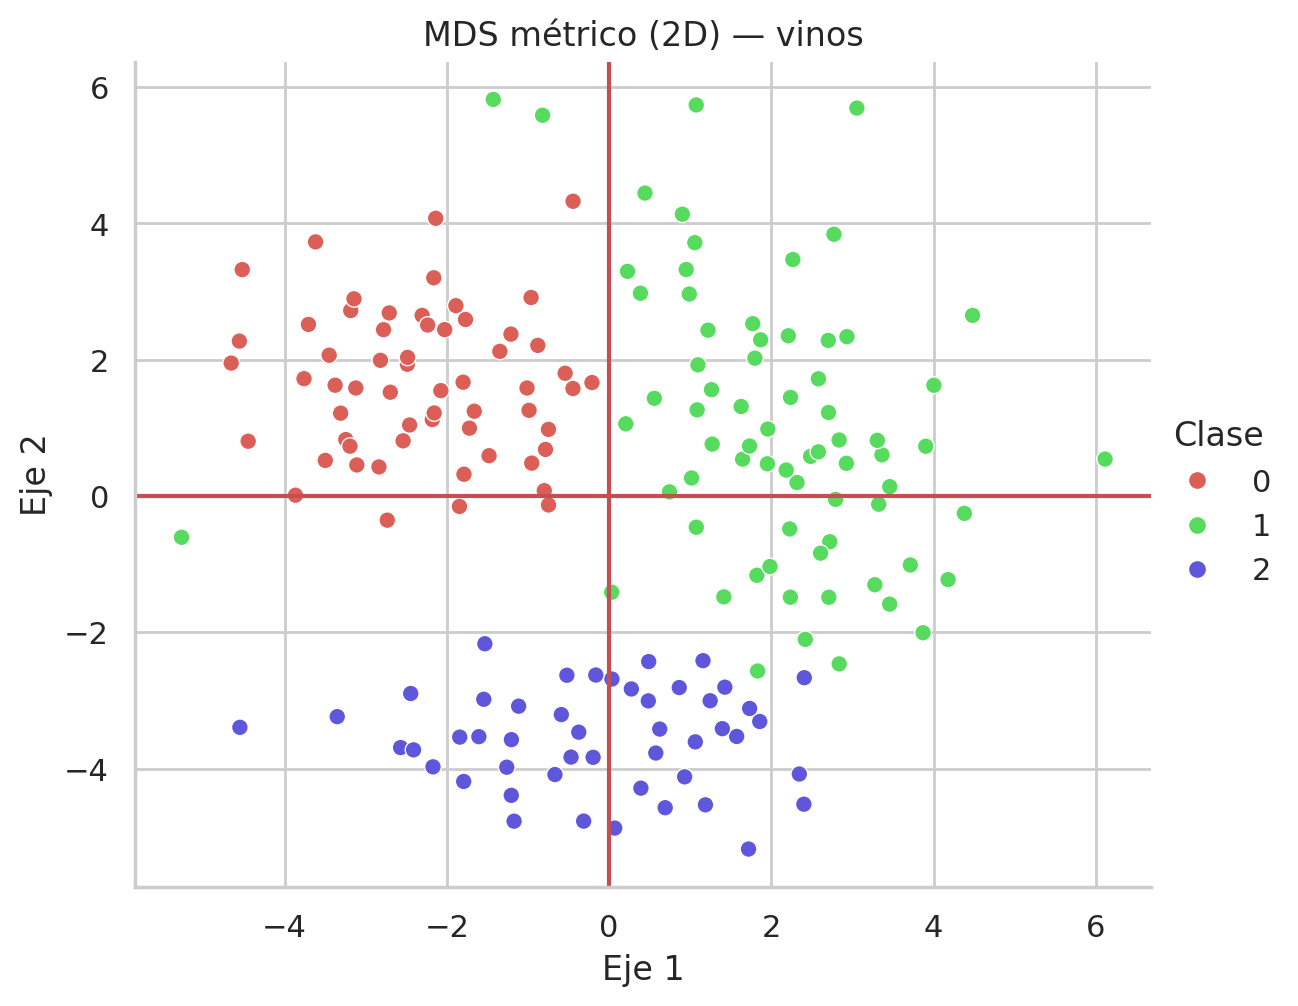

In [5]:
pts = ajustar_mds(Mdist_vinos, n_components=2, metrico=True)
proj = pd.DataFrame(pts, columns=['MDS1', 'MDS2'])
proj['Clase'] = y_vinos.values

sns.relplot(data=proj, x='MDS1', y='MDS2', hue='Clase',
            palette=sns.color_palette('hls', 3), height=5, aspect=1.2)
plt.axvline(0, color='r'); plt.axhline(0, color='r')
plt.xlabel('Eje 1'); plt.ylabel('Eje 2'); plt.title('MDS métrico (2D) — vinos'); plt.show()

**Interpretación.** La proyección 2D separa razonablemente las tres clases: el **eje 1** separa sobre todo las clases 0 y 2 (quedan a lados opuestos), mientras que la clase 1 se distingue mejor en el **eje 2**, situándose en una banda intermedia. Es una primera señal de que las clases son distinguibles, aunque con cierto solapamiento en la frontera.

Para juzgar si **dos dimensiones bastan**, comparamos las distancias originales con las proyectadas.

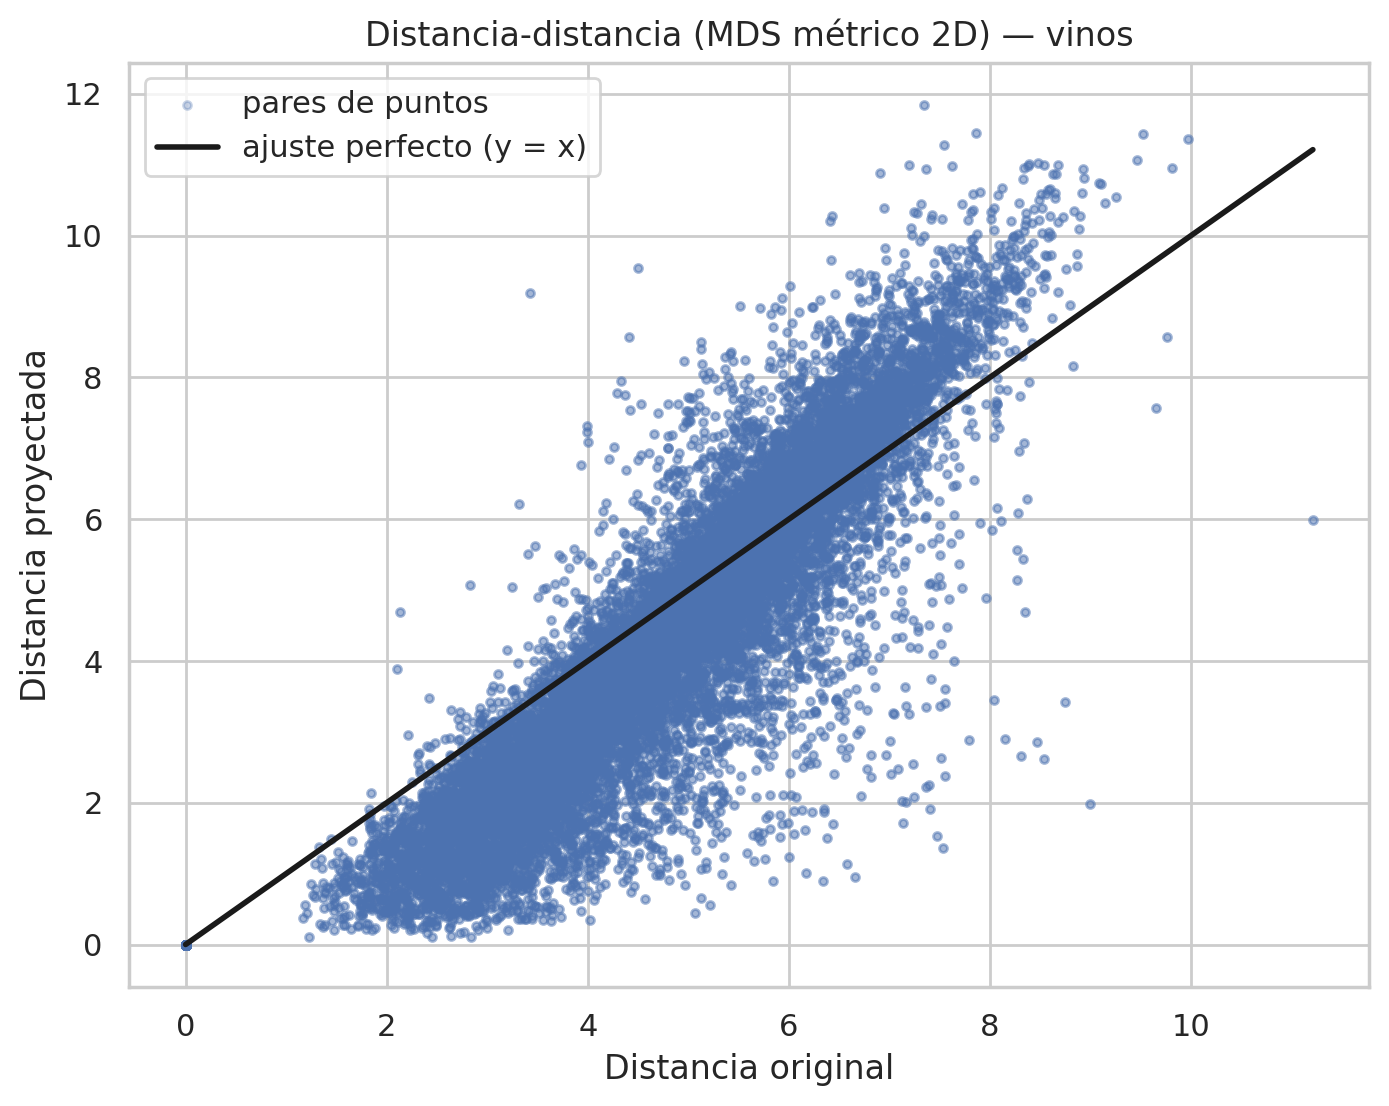

In [6]:
grafico_distancias(Mdist_vinos, pts, 'Distancia-distancia (MDS métrico 2D) — vinos')

**Interpretación.** La nube **no se ajusta bien** a la diagonal: para muchas parejas la distancia proyectada queda muy por debajo de la real, señal de que dos dimensiones **comprimen demasiado** la estructura. Necesitamos más ejes. Lo cuantificamos con la curva de Stress-1.



 1 dim -> Stress-1 = 0.508
 2 dim -> Stress-1 = 0.237
 3 dim -> Stress-1 = 0.146
 4 dim -> Stress-1 = 0.102
 5 dim -> Stress-1 = 0.072
 6 dim -> Stress-1 = 0.053
 7 dim -> Stress-1 = 0.038
 8 dim -> Stress-1 = 0.030
 9 dim -> Stress-1 = 0.023
10 dim -> Stress-1 = 0.018


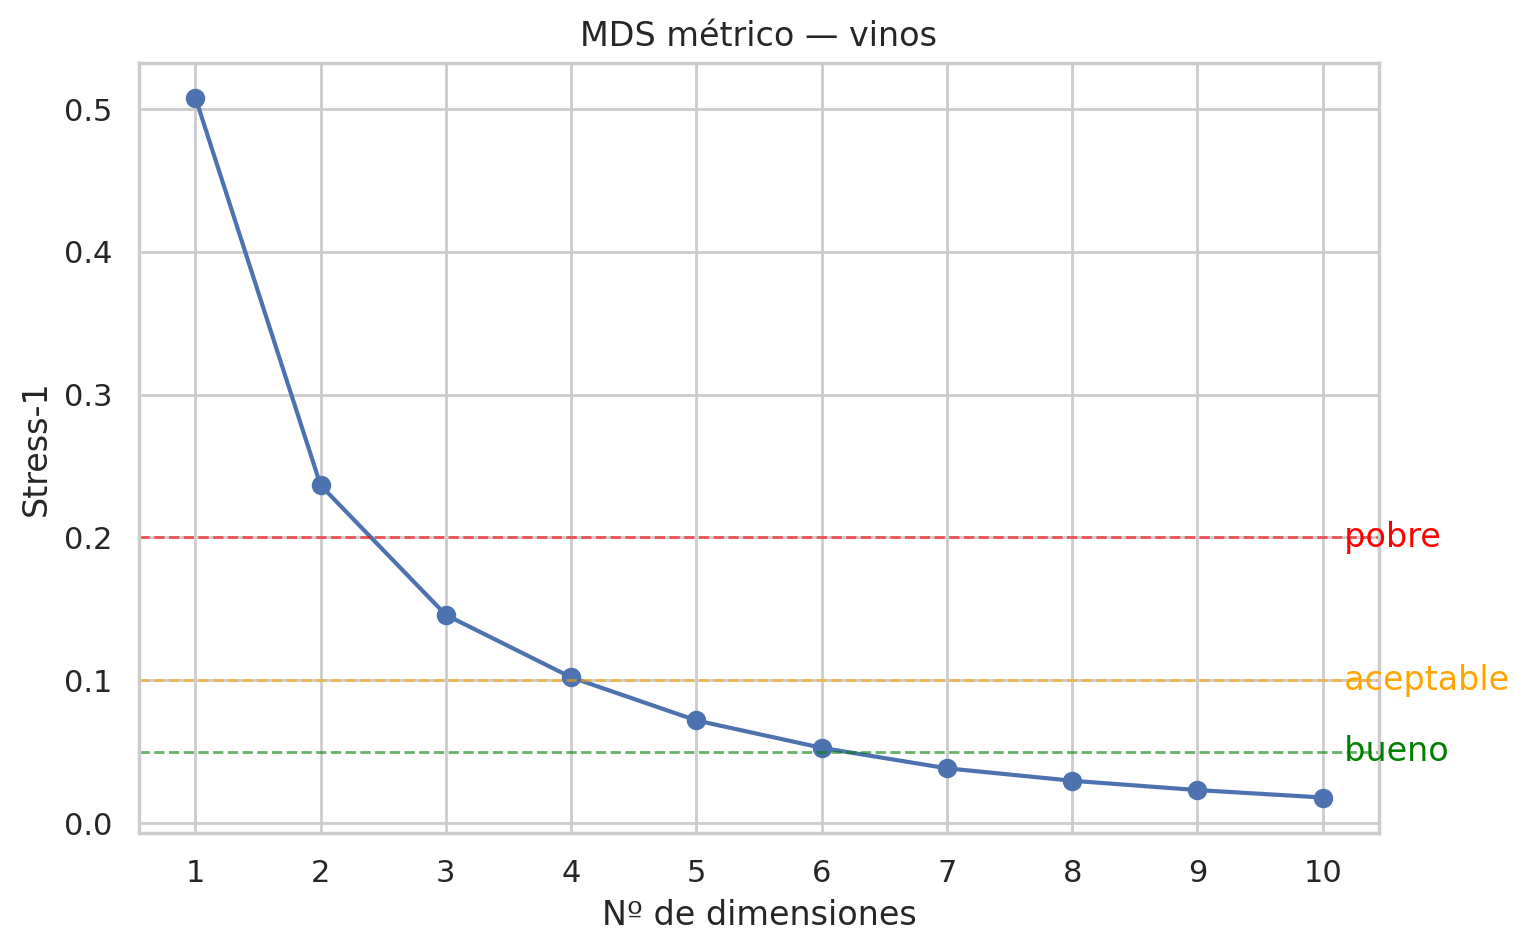

In [7]:
dims, s_metrico = curva_stress(Mdist_vinos, metrico=True, max_dim=10)
for d, s in zip(dims, s_metrico): print(f'{d:>2} dim -> Stress-1 = {s:.3f}')
grafico_codo(dims, s_metrico, 'MDS métrico — vinos')

**Interpretación (valores reales).** El Stress-1 baja así: **1D ≈ 0.51, 2D ≈ 0.24, 3D ≈ 0.15, 4D ≈ 0.10, 5D ≈ 0.07, 6D ≈ 0.05**. Leído con la tabla de Kruskal:

* **2D (0.24)** está en zona **inaceptable**, lo que confirma lo que veíamos en el gráfico distancia-distancia.
* **4D (≈0.10)** entra justo en la frontera de ajuste **aceptable**, y la curva ya se ha aplanado bastante.
* A partir de **5D (≈0.07)** el ajuste es **bueno**, con mejoras pequeñas al añadir más ejes.

Una buena elección es **4 ejes** (codo + ajuste aceptable), o **5** si queremos un ajuste "bueno". Hemos reducido de 13 variables a 4–5 ejes que podrían alimentar después un clasificador (p. ej. *naïve Bayes*). Nótese que con 4 ejes ya no podemos visualizar la proyección directamente.

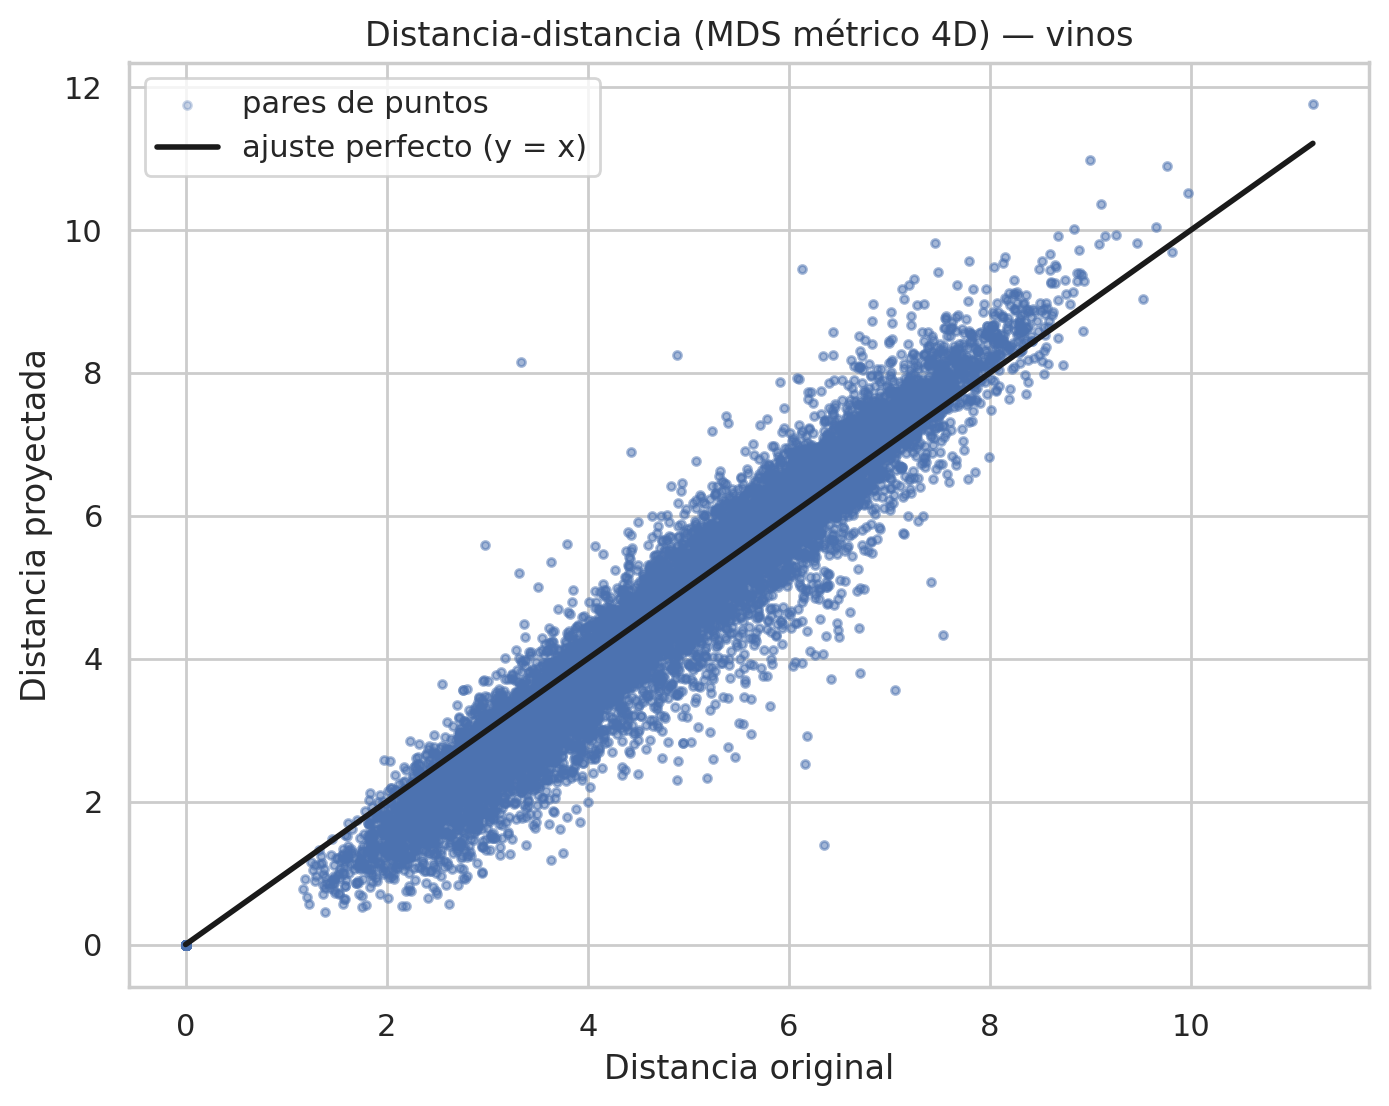

In [8]:
# Solución con 4 componentes: el ajuste distancia-distancia debe mejorar
pts4 = ajustar_mds(Mdist_vinos, n_components=4, metrico=True)
grafico_distancias(Mdist_vinos, pts4, 'Distancia-distancia (MDS métrico 4D) — vinos')

**Interpretación.** Ahora la nube **sí se sitúa sobre la diagonal**: con 4 ejes las distancias se preservan mucho mejor que con 2, en línea con la caída del Stress-1.

### <font color="steelblue">MDS no métrico</font>

Repetimos el análisis exigiendo solo conservar el **orden** de las distancias.

 1 dim -> Stress-1 = 6.986
 2 dim -> Stress-1 = 6.709
 3 dim -> Stress-1 = 6.544
 4 dim -> Stress-1 = 6.468
 5 dim -> Stress-1 = 6.424
 6 dim -> Stress-1 = 6.386
 7 dim -> Stress-1 = 6.375
 8 dim -> Stress-1 = 6.356
 9 dim -> Stress-1 = 6.342
10 dim -> Stress-1 = 6.339


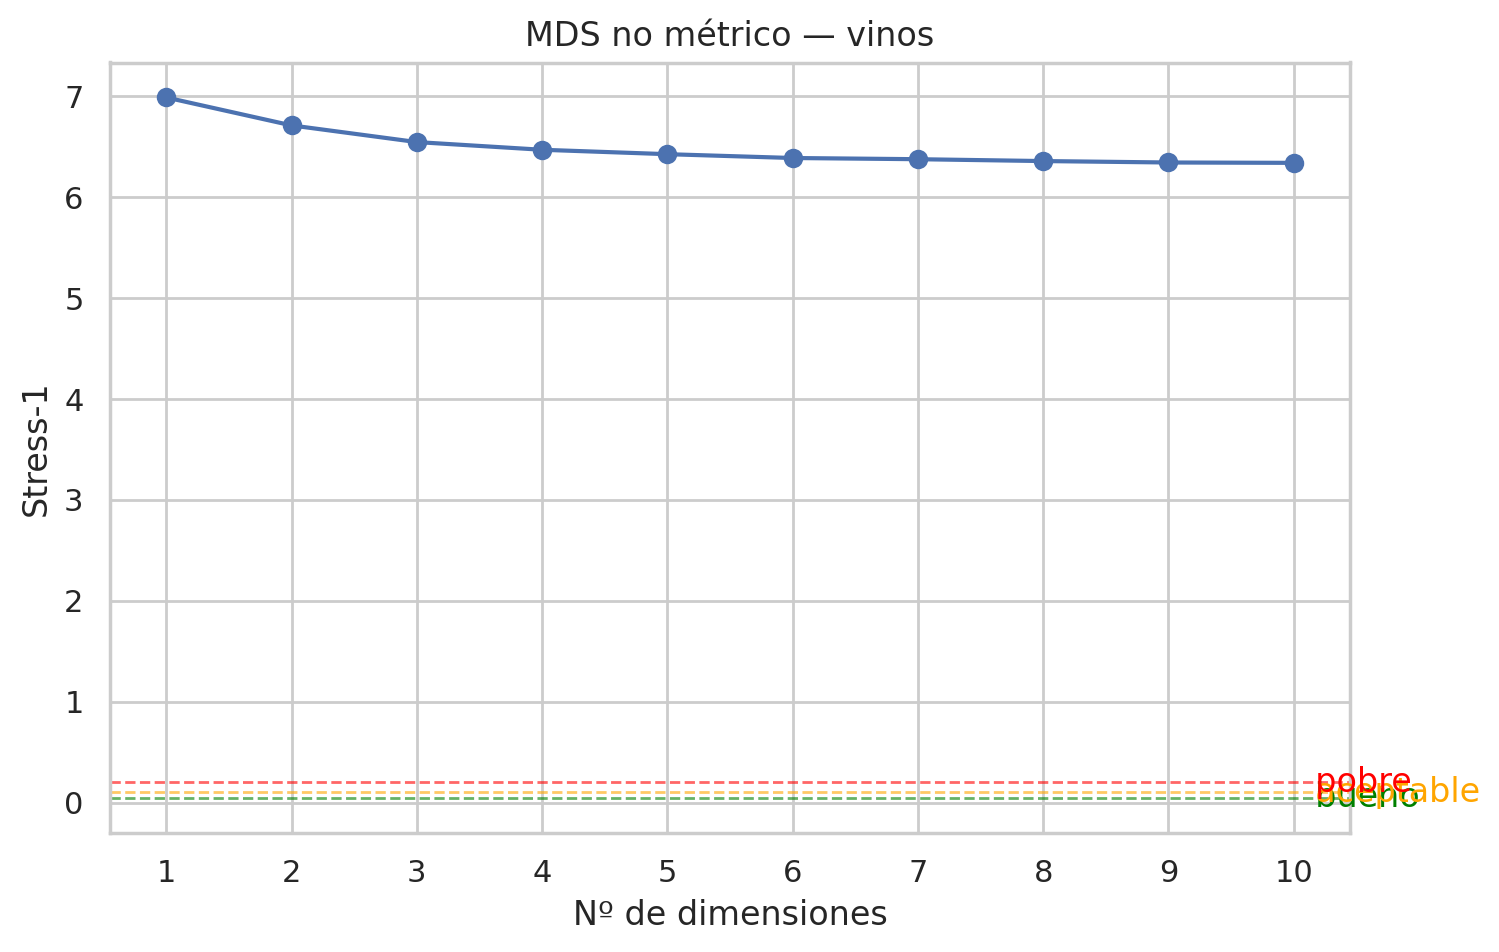

In [9]:
dims, s_nometrico = curva_stress(Mdist_vinos, metrico=False, max_dim=10)
for d, s in zip(dims, s_nometrico): print(f'{d:>2} dim -> Stress-1 = {s:.3f}')
grafico_codo(dims, s_nometrico, 'MDS no métrico — vinos')

**Interpretación y matiz importante.** Con el **Stress-1** (comparable entre ambos métodos) el no métrico da valores muy parecidos —o ligeramente menores— que el métrico a igual número de ejes (p. ej. ~0.20 en 2D, ~0.11 en 3D, ~0.06 en 5D). Esto tiene sentido: al imponer solo el orden, el no métrico es **más flexible** y puede igualar o mejorar el ajuste por dimensión.

> **Corrección a una confusión habitual:** a veces se concluye que "el no métrico necesita más dimensiones". Eso ocurre cuando se compara el stress **crudo** del métrico con el **normalizado** del no métrico (escalas distintas e incomparables). Usando el **Stress-1 en ambos**, la comparación es justa. Aquí, tanto métrico como no métrico sugieren **4–5 ejes**; nos quedamos con el **MDS métrico de 4 ejes** por simplicidad e interpretabilidad.

## <font color="steelblue">4.2. Sales</font>

El banco `sales` recoge las **cantidades compradas semanalmente** de cada producto durante un año (**52 semanas → 52 variables** `W0…W51`). El objetivo es **reducir la dimensión** para luego agrupar productos con patrones de venta parecidos. No hay variable objetivo (problema no supervisado).

In [10]:
url = 'https://raw.githubusercontent.com/ia4legos/MachineLearning/main/data/Sales_Transactions_Weekly.csv'
sales = pd.read_csv(url)
X_sales = sales.drop(columns='Product_Code')
print('Dimensiones:', X_sales.shape)

X_sales_std = StandardScaler().fit_transform(X_sales)
Mdist_sales = pairwise_distances(X_sales_std)

Dimensiones: (811, 52)


### <font color="steelblue">MDS métrico — proyección 2D</font>

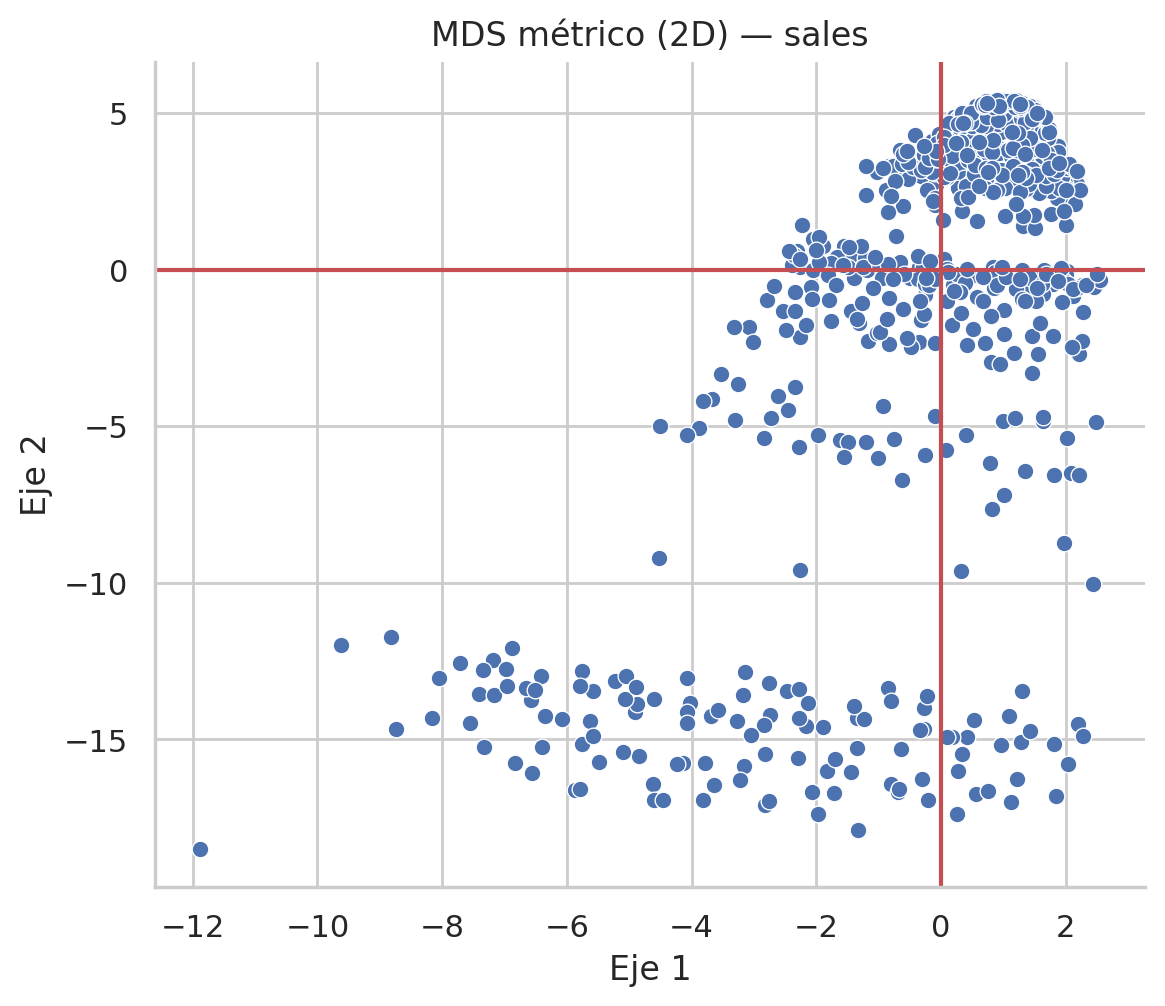

In [11]:
pts_sales = ajustar_mds(Mdist_sales, n_components=2, metrico=True)
proj_sales = pd.DataFrame(pts_sales, columns=['MDS1', 'MDS2'])

sns.relplot(data=proj_sales, x='MDS1', y='MDS2', height=5, aspect=1.2)
plt.axvline(0, color='r'); plt.axhline(0, color='r')
plt.xlabel('Eje 1'); plt.ylabel('Eje 2'); plt.title('MDS métrico (2D) — sales'); plt.show()

**Interpretación.** Al no haber etiquetas no coloreamos por clase, pero la nube ya **sugiere agrupaciones** separadas principalmente por el **volumen de compra** a lo largo del eje 1: se intuyen del orden de **cuatro grupos** de productos según su nivel de ventas. Esos ejes servirán de entrada a un algoritmo de *clustering* más adelante.

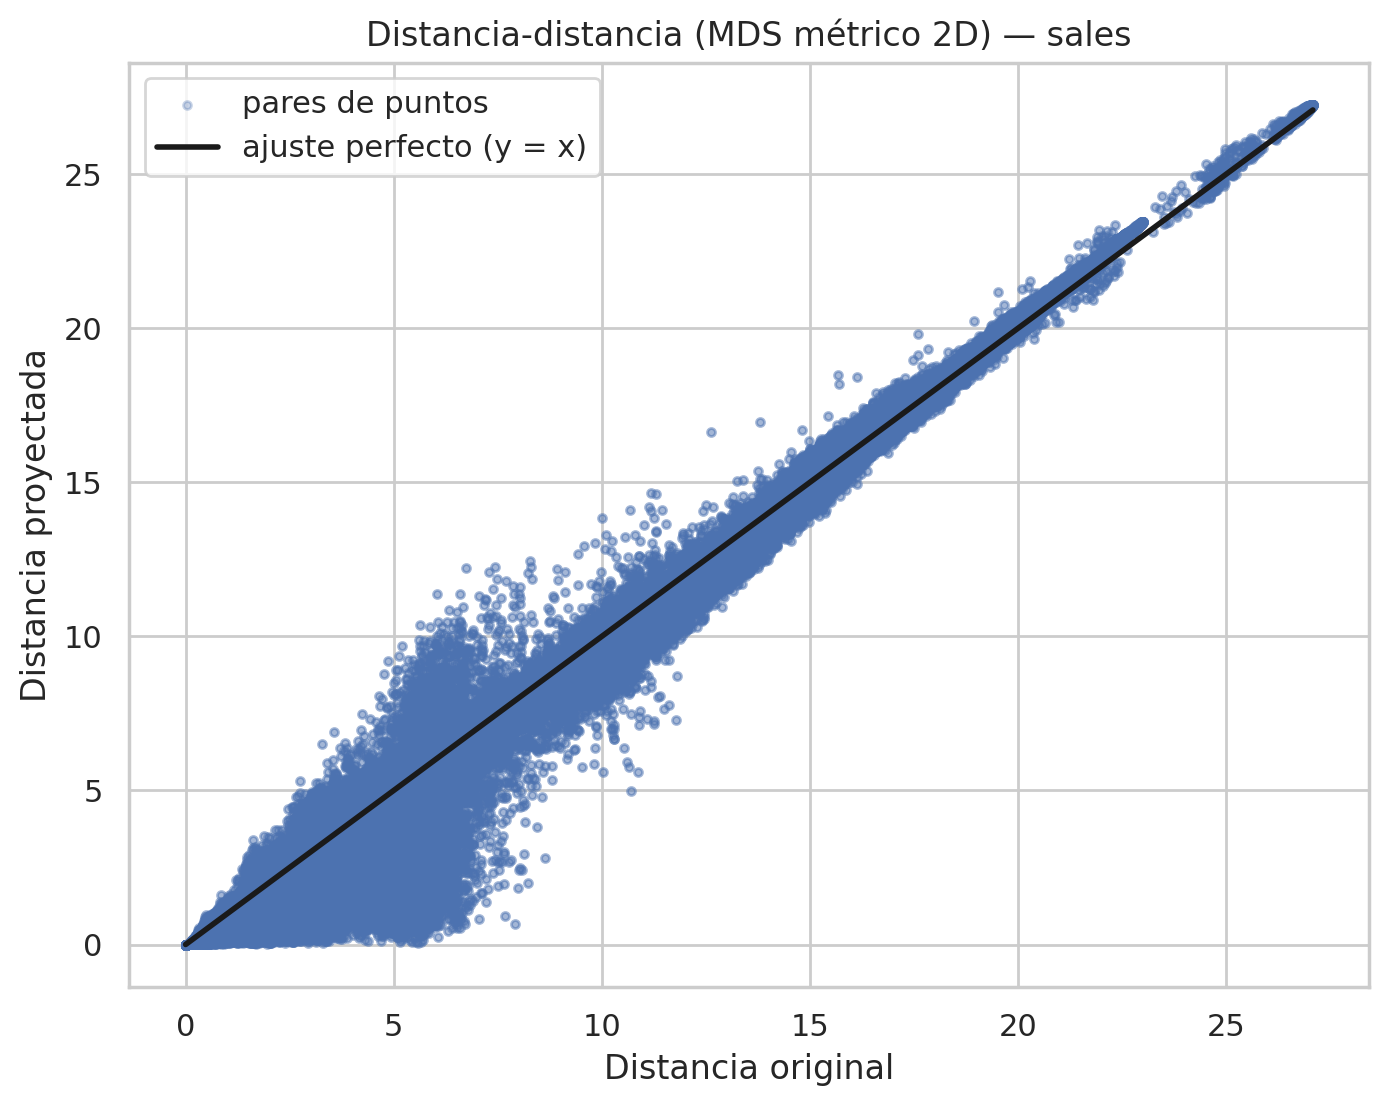

In [12]:
grafico_distancias(Mdist_sales, pts_sales, 'Distancia-distancia (MDS métrico 2D) — sales')

**Interpretación.** Aquí, a diferencia de los vinos, la nube **se ajusta muy bien a la diagonal** ya en 2D (con algo más de dispersión en las distancias pequeñas, a la izquierda). Esto anticipa un Stress-1 bajo con solo dos ejes.

 1 dim -> Stress-1 = 0.425
 2 dim -> Stress-1 = 0.058
 3 dim -> Stress-1 = 0.044
 4 dim -> Stress-1 = 0.035
 5 dim -> Stress-1 = 0.030
 6 dim -> Stress-1 = 0.027
 7 dim -> Stress-1 = 0.024
 8 dim -> Stress-1 = 0.023
 9 dim -> Stress-1 = 0.021
10 dim -> Stress-1 = 0.020


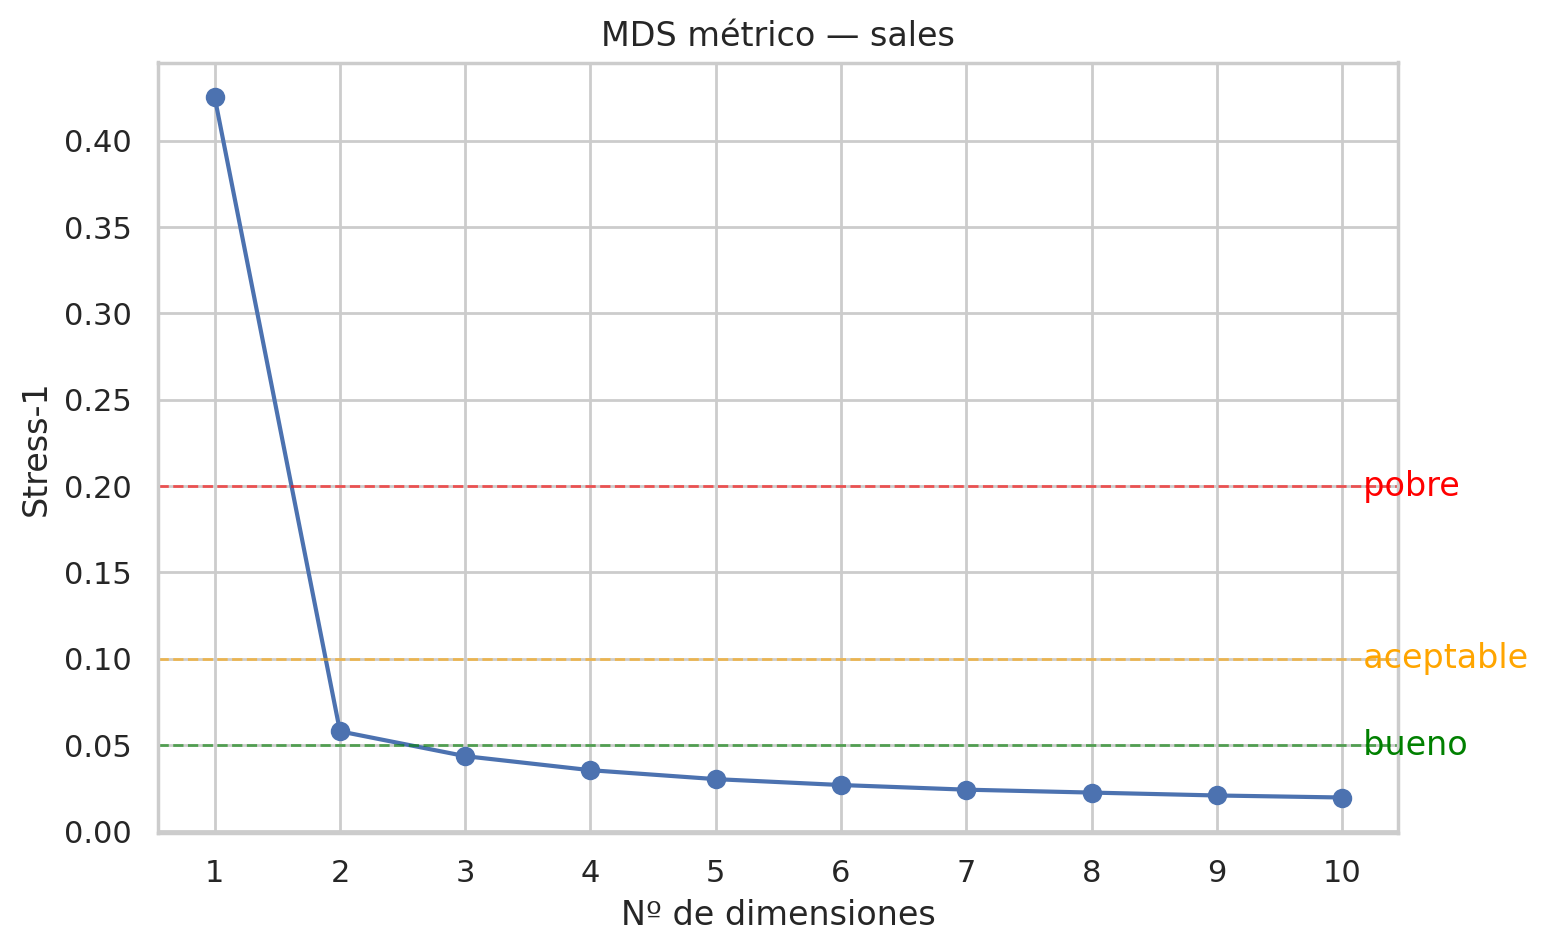

In [13]:
dims, s_sales = curva_stress(Mdist_sales, metrico=True, max_dim=10)
for d, s in zip(dims, s_sales): print(f'{d:>2} dim -> Stress-1 = {s:.3f}')
grafico_codo(dims, s_sales, 'MDS métrico — sales')

**Interpretación (valores reales).** La caída es **drástica de 1D a 2D**: **1D ≈ 0.44 (inaceptable) → 2D ≈ 0.059 (bueno)**, y a partir de ahí la curva está casi plana (3D ≈ 0.045, 4D ≈ 0.037…). El **codo es nítido en 2 dimensiones** y, además, el 2D ya cae en zona de ajuste **bueno**. Por tanto, **2 ejes son suficientes**: hemos reducido de 52 variables a 2 ejes que capturan casi toda la estructura de distancias, ideales para visualizar y para el *clustering* posterior (los ~4 grupos que se intuían).

El MDS **no métrico** da una curva análoga (2D ≈ 0.04, aún mejor), confirmando que dos dimensiones bastan.

## <font color="steelblue">4.4. Olivetti faces</font>

El conjunto `Olivetti faces` (AT&T) contiene **10 imágenes de 64×64 por persona**, con distintas expresiones e iluminaciones. Para no saturar el gráfico tomamos solo las caras de **6 personas** (60 imágenes) y aplicamos MDS, con el objetivo de **agrupar las imágenes de una misma persona**.

> Cada imagen son **4096 píxeles** (64×64): la reducción de dimensión es imprescindible. (Este dataset se **descarga** la primera vez; en Colab funciona sin problema.)

In [32]:
# Descargamos el fichero desde el repositorio GitHub
raw_github_url = "https://raw.githubusercontent.com/ia4legos/MachineLearning/main/data/olivettifaces.mat"
local_filename = "olivettifaces_downloaded.mat"
urllib.request.urlretrieve(raw_github_url, local_filename)
mfile = loadmat(local_filename)

# Construímos los objetos necesarios
faces  = np.float32(mfile["faces"].T.copy())
faces  = faces - faces.min(); faces /= faces.max()
images = faces.reshape((400, 64, 64)).transpose(0, 2, 1)
X_faces = images.reshape(400, -1)                 # (400, 4096)
y_faces = np.array([i // 10 for i in range(400)])
ind = y_faces < 6
X_faces, y_faces = X_faces[ind], y_faces[ind]

### <font color="steelblue">MDS métrico — proyección 2D con las caras</font>

Mostramos la proyección 2D de dos formas: coloreando por persona y, a la derecha, dibujando cada cara en su posición.

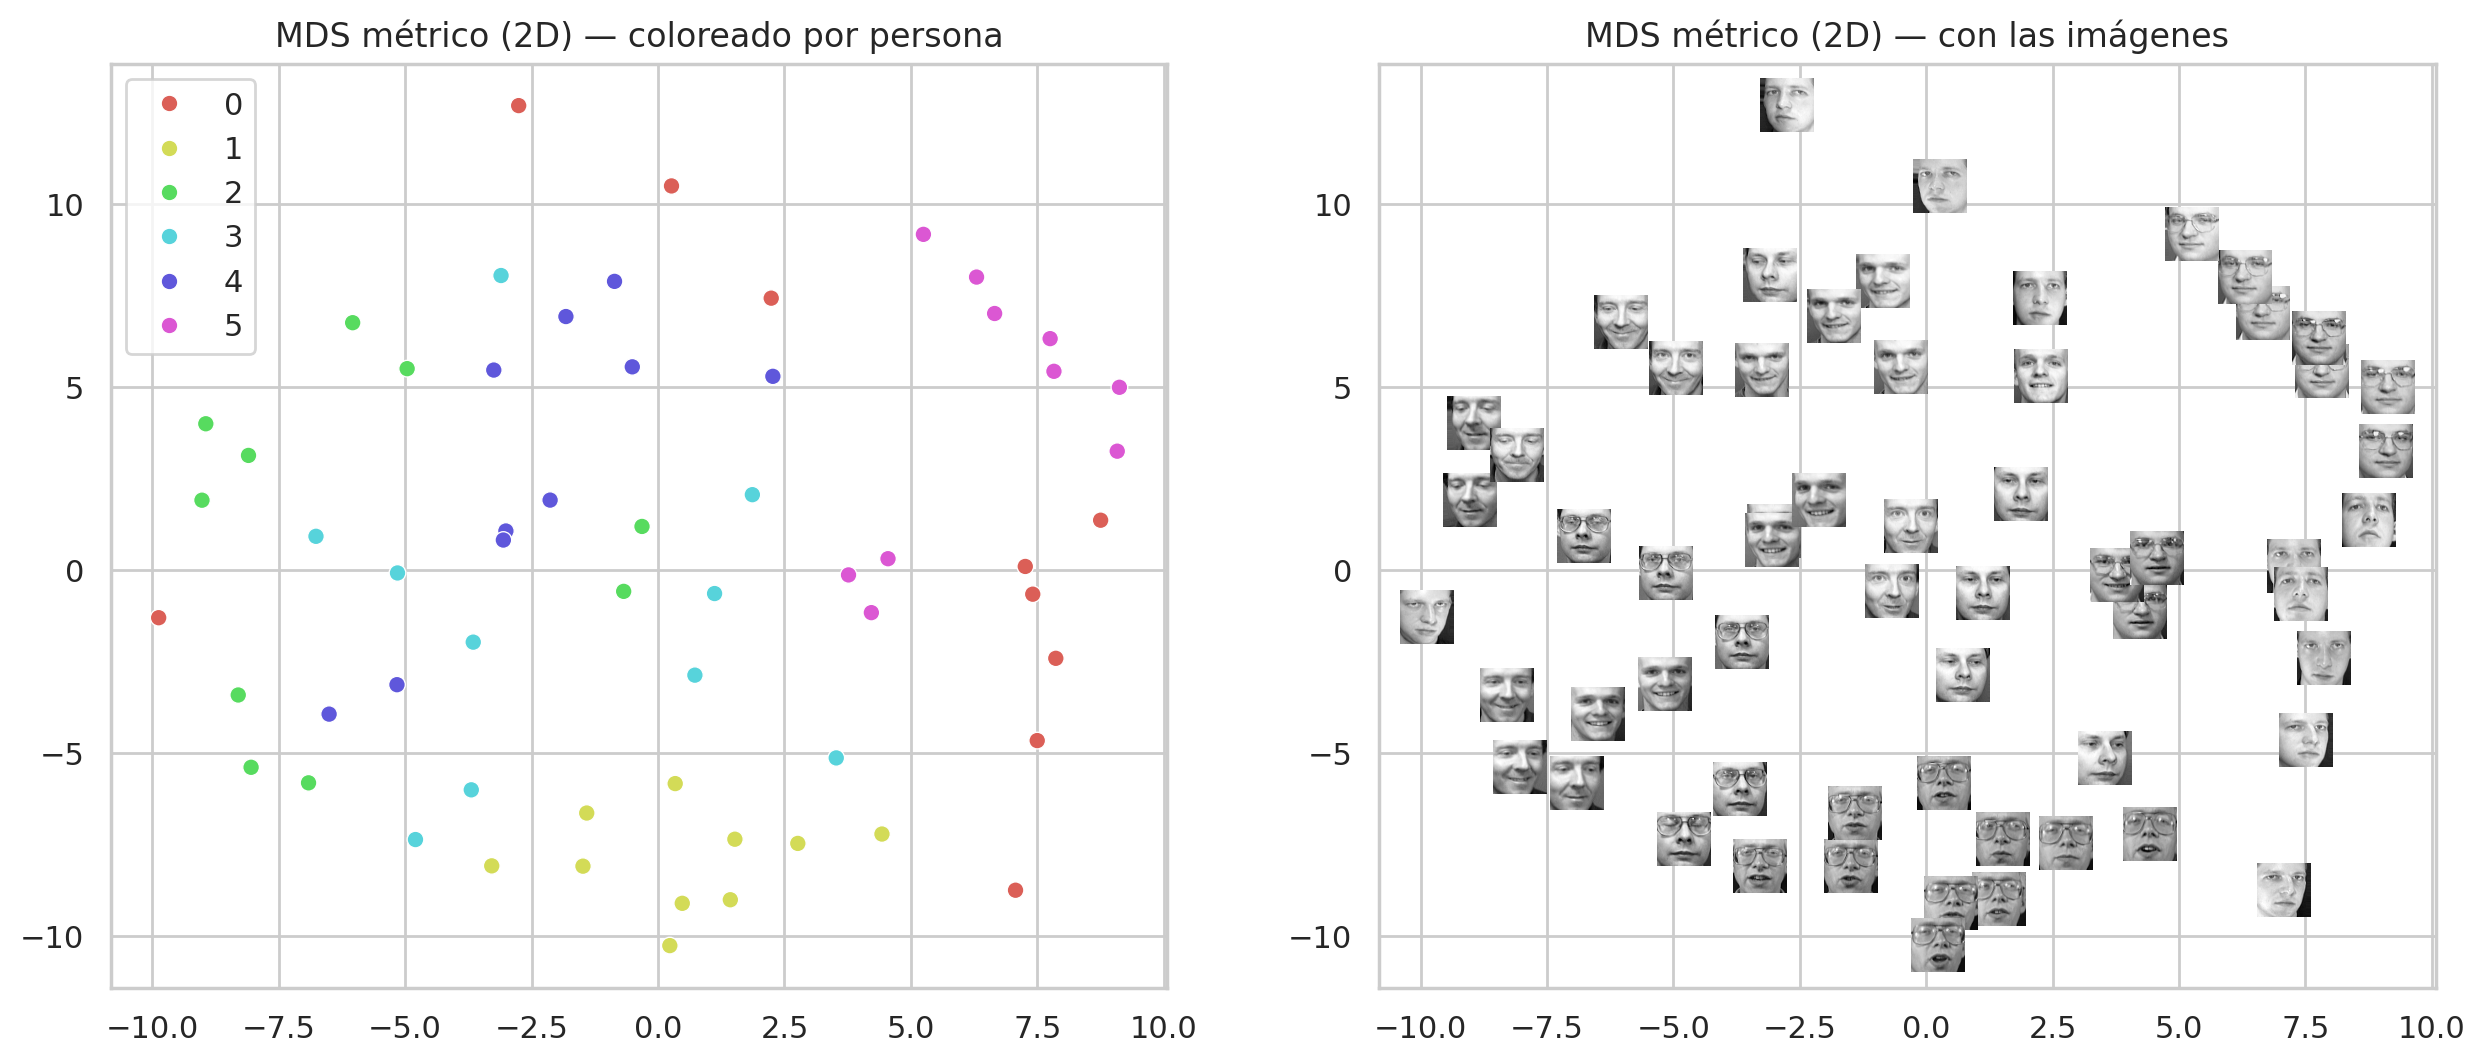

In [33]:
# Matriz de distancias
Mdist_faces = pairwise_distances(X_faces)

# Representación gráfica
pts_faces = ajustar_mds(Mdist_faces, n_components=2, metrico=True, random_state=1)

fig = plt.figure(figsize=(15, 6))
ax1 = fig.add_subplot(1, 2, 1)
sns.scatterplot(x=pts_faces[:, 0], y=pts_faces[:, 1], hue=grupos,
                palette=sns.color_palette('hls', 6), ax=ax1)
ax1.set_title('MDS métrico (2D) — coloreado por persona')

ax2 = fig.add_subplot(1, 2, 2)
ax2.scatter(pts_faces[:, 0], pts_faces[:, 1])
for x, (i, j) in zip(X_faces, pts_faces):
    imagebox = OffsetImage(x.reshape(64, 64), zoom=0.3, cmap=plt.cm.gray)
    ax2.add_artist(AnnotationBbox(imagebox, (i, j), frameon=False))
ax2.set_title('MDS métrico (2D) — con las imágenes')
plt.show()

**Interpretación.** En dos dimensiones el MDS **agrupa parcialmente** las caras de la misma persona, pero **no separa limpiamente a los 6 sujetos**: algunas personas se mezclan porque, en el espacio de 4096 píxeles, los cambios de expresión e iluminación generan tanta variación como el cambio de identidad. Necesitamos más ejes; lo evaluamos con la curva de stress.

 1 dim -> Stress-1 = 0.606
 2 dim -> Stress-1 = 0.277
 3 dim -> Stress-1 = 0.175
 4 dim -> Stress-1 = 0.128
 5 dim -> Stress-1 = 0.102
 6 dim -> Stress-1 = 0.085
 7 dim -> Stress-1 = 0.072
 8 dim -> Stress-1 = 0.064
 9 dim -> Stress-1 = 0.057
10 dim -> Stress-1 = 0.051


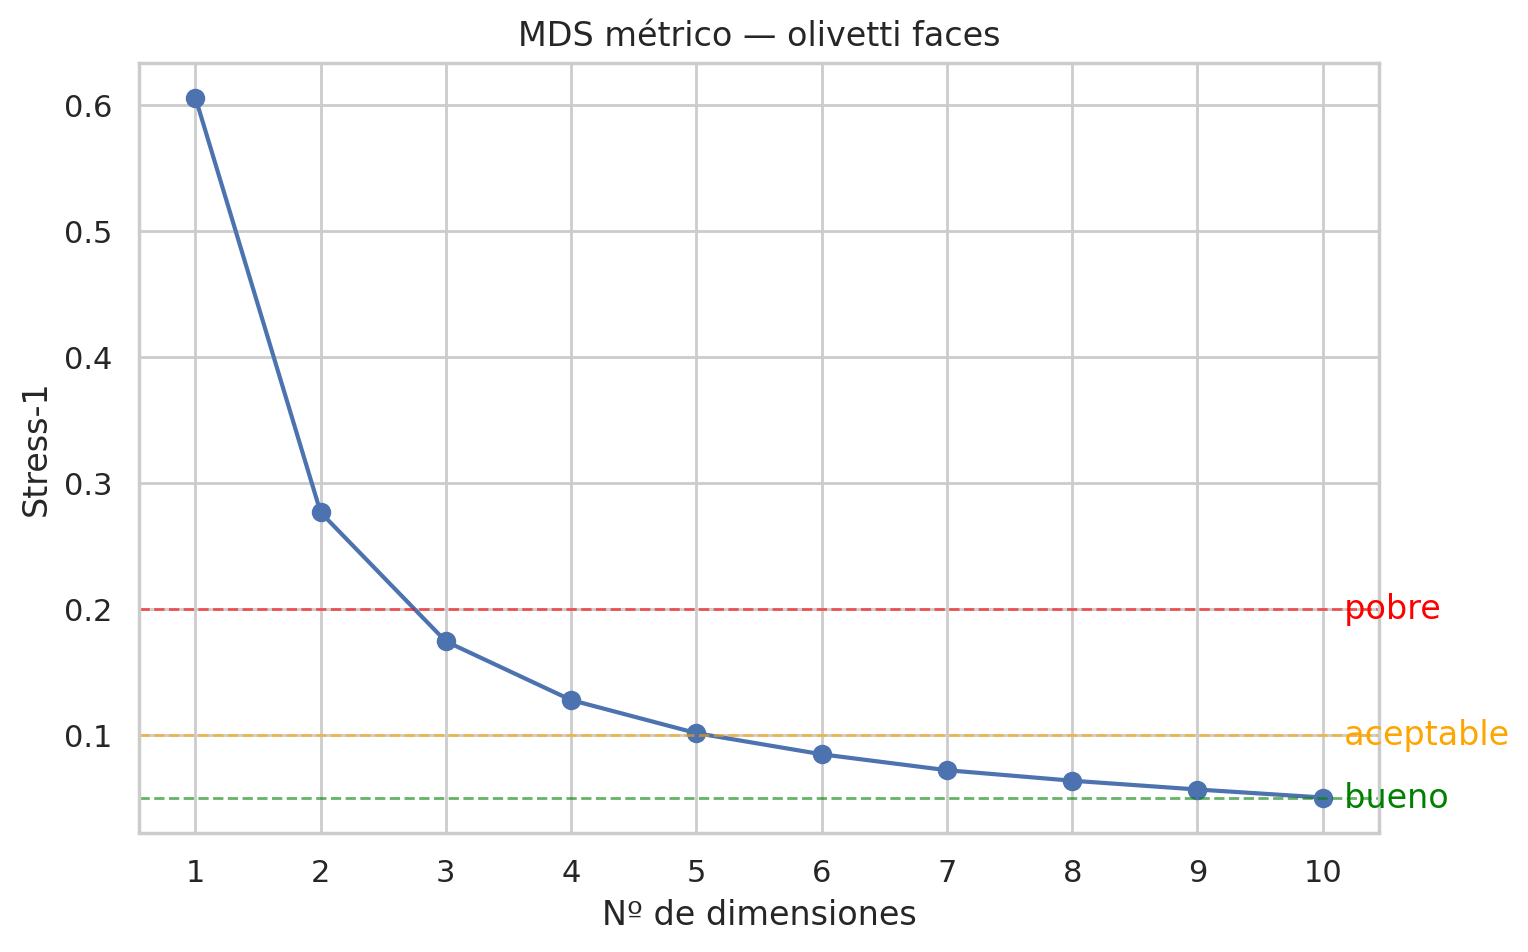

In [34]:
dims, s_faces = curva_stress(Mdist_faces, metrico=True, max_dim=10, n_init=4)
for d, s in zip(dims, s_faces): print(f'{d:>2} dim -> Stress-1 = {s:.3f}')
grafico_codo(dims, s_faces, 'MDS métrico — olivetti faces')

**Interpretación.** Partiendo de **4096 dimensiones**, la curva se aplana pronto: una solución de **~4 ejes** captura la mayor parte de la estructura de distancias con un Stress-1 razonable. La reducción es enorme (4096 → 4).

### <font color="steelblue">Comparar la métrica de distancia: euclídea vs Manhattan</font>

Como el MDS parte de una matriz de distancias, podemos probar **otra métrica**. Repetimos con la distancia de **Manhattan** (suma de diferencias absolutas), que en alta dimensión a veces separa mejor.

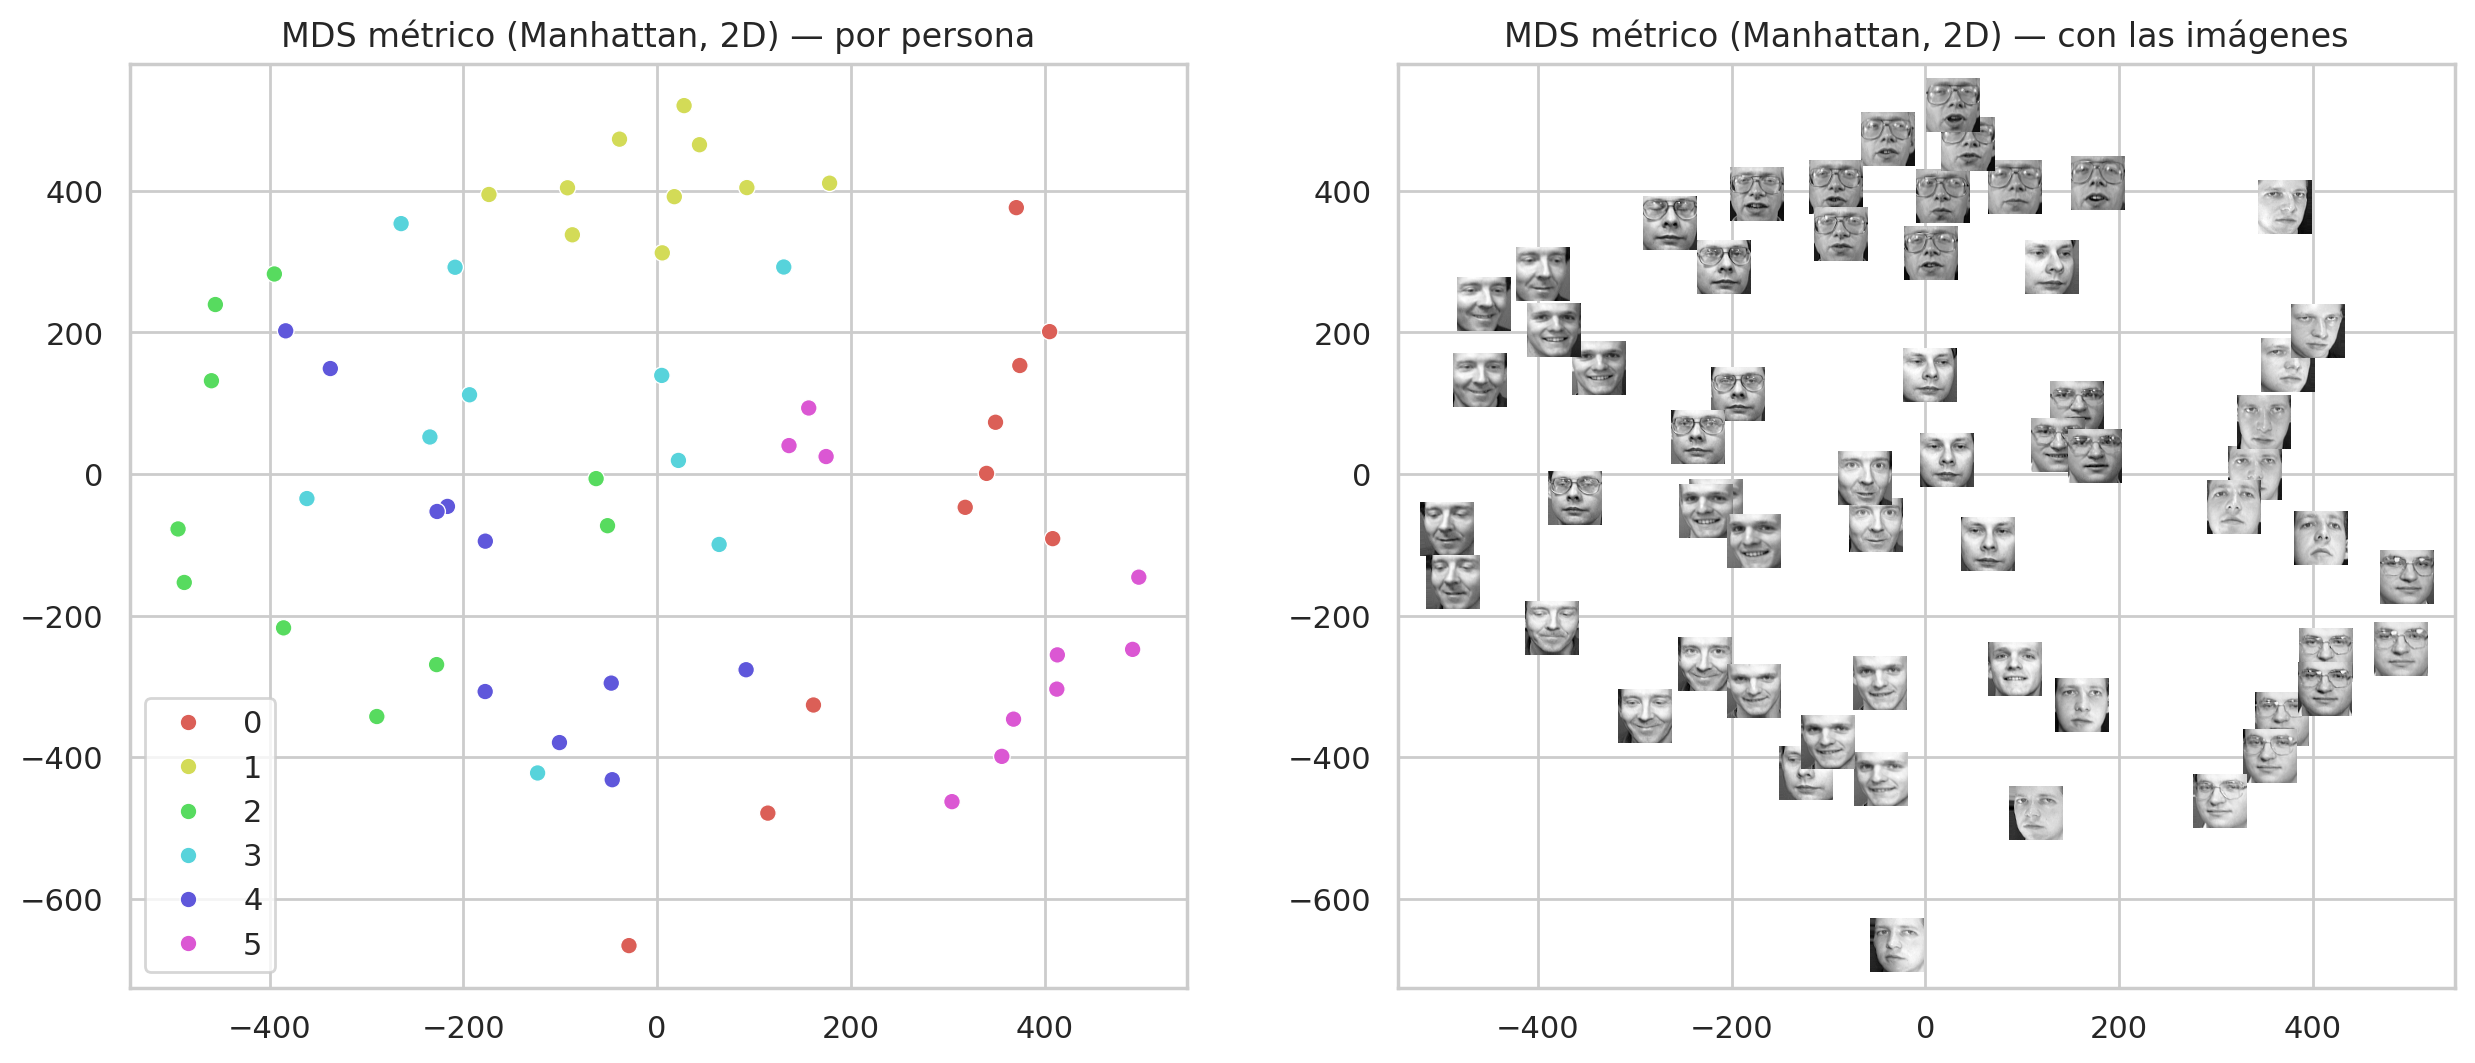

In [35]:
Mdist_faces_man = pairwise_distances(X_faces, metric='manhattan')
pts_faces_man = ajustar_mds(Mdist_faces_man, n_components=2, metrico=True, random_state=1)

fig = plt.figure(figsize=(15, 6))
ax1 = fig.add_subplot(1, 2, 1)
sns.scatterplot(x=pts_faces_man[:, 0], y=pts_faces_man[:, 1], hue=grupos,
                palette=sns.color_palette('hls', 6), ax=ax1)
ax1.set_title('MDS métrico (Manhattan, 2D) — por persona')

ax2 = fig.add_subplot(1, 2, 2)
ax2.scatter(pts_faces_man[:, 0], pts_faces_man[:, 1])
for x, (i, j) in zip(X_faces, pts_faces_man):
    imagebox = OffsetImage(x.reshape(64, 64), zoom=0.3, cmap=plt.cm.gray)
    ax2.add_artist(AnnotationBbox(imagebox, (i, j), frameon=False))
ax2.set_title('MDS métrico (Manhattan, 2D) — con las imágenes')
plt.show()

**Interpretación.** La solución con **Manhattan** es parecida a la euclídea pero suele **separar algo mejor** los grupos de imágenes. Es un buen recordatorio de la ventaja del MDS: al trabajar sobre distancias, **cambiar la métrica** es inmediato y puede mejorar el resultado sin tocar el resto del flujo.



### <font color="steelblue">MDS no métrico</font>

 1 dim -> Stress-1 = 16.740
 2 dim -> Stress-1 = 16.242
 3 dim -> Stress-1 = 15.855
 4 dim -> Stress-1 = 15.733
 5 dim -> Stress-1 = 15.618
 6 dim -> Stress-1 = 15.581
 7 dim -> Stress-1 = 15.591
 8 dim -> Stress-1 = 15.528
 9 dim -> Stress-1 = 15.511
10 dim -> Stress-1 = 15.500


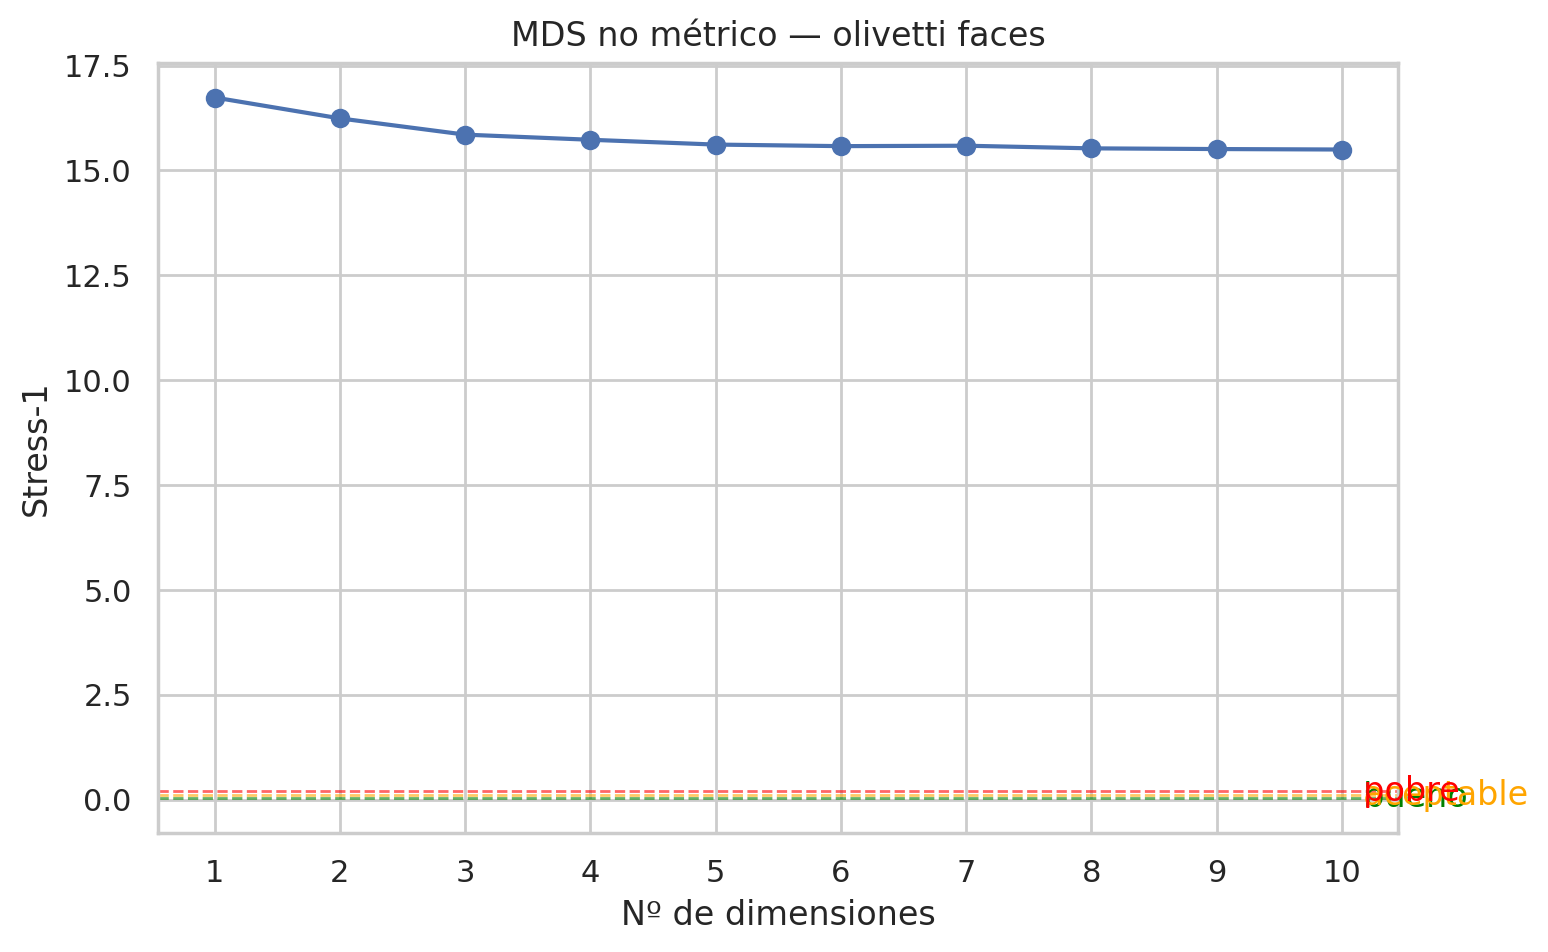

In [36]:
dims, s_faces_nm = curva_stress(Mdist_faces, metrico=False, max_dim=10, n_init=4)
for d, s in zip(dims, s_faces_nm): print(f'{d:>2} dim -> Stress-1 = {s:.3f}')
grafico_codo(dims, s_faces_nm, 'MDS no métrico — olivetti faces')

**Interpretación y conclusión.** Como en los demás ejemplos, el MDS **no métrico** alcanza un ajuste comparable al métrico (con el Stress-1 normalizado). Por simplicidad e interpretabilidad, la **solución que adoptamos es el MDS métrico con 4 ejes** (con distancia euclídea o Manhattan), que reduce drásticamente la dimensión conservando bien la estructura de distancias entre las imágenes.

# <font color="steelblue">5. Conclusiones</font>

Recogemos las ideas principales del cuaderno.

**Sobre el método.**
- El MDS reduce la dimensión **preservando las distancias** entre puntos. Su diferencia esencial con el PCA es el **punto de partida**: el PCA necesita la matriz de características $X$; el MDS, solo una **matriz de disimilitudes**. Por eso admite cualquier métrica e incluso disimilitudes que no provienen de coordenadas. Cuando las distancias son euclídeas, el **MDS clásico coincide con el PCA**.
- Distinguimos el MDS **métrico** (respeta los *valores* de las distancias) del **no métrico** (respeta solo su *orden*, idóneo para datos ordinales). En la práctica, medidos ambos con el **Stress-1**, dan ajustes comparables por dimensión.

**Sobre la validación (lo más importante para decidir).**
- La calidad debe medirse con el **Stress-1 normalizado**, no con el stress crudo: este último **siempre** decrece al añadir ejes, lo que hace engañoso el criterio del codo. El Stress-1 está acotado en $[0,1]$ y tiene una interpretación estándar (excelente ≤ 0.025, bueno ≤ 0.05, aceptable ≤ 0.10…).
- El número de ejes se elige combinando la **curva de Stress-1** (codo + zona de ajuste bueno/aceptable) con los gráficos **distancia-distancia** y de **Shepard**.

**Sobre los ejemplos.**
- **Wine:** 2D es insuficiente (Stress-1 ≈ 0.24, inaceptable); hacen falta **4–5 ejes** para un ajuste aceptable/bueno. Se reduce de 13 variables a 4–5 ejes útiles para un clasificador posterior.
- **Sales:** caída drástica de 1D a 2D (≈ 0.44 → ≈ 0.06); **2 ejes bastan** para resumir las 52 semanas, ideales para visualizar y para el *clustering* (se intuyen ~4 grupos de productos).
- **Olivetti faces:** partiendo de 4096 dimensiones, **~4 ejes** capturan la estructura; cambiar a la métrica de **Manhattan** separa algo mejor las identidades, ilustrando la flexibilidad del MDS.

**¿Cuándo elegir MDS frente a PCA?** Cuando solo dispones de distancias/disimilitudes (no de coordenadas), cuando quieres una **métrica no euclídea** o trabajas con datos **ordinales** (no métrico), o cuando buscas una representación que **preserve distancias** para visualizar o como entrada a un *clustering*.

En el **siguiente cuaderno** abordamos otros dos métodos de aprendizaje de variedades —**LLE** e **Isomap**— que, a diferencia del MDS, se centran en preservar la estructura **local** o las distancias **geodésicas** sobre la variedad, y capturan mejor las estructuras no lineales "enrolladas".

# <font color="steelblue">Referencias y enlaces de interés</font>





Manuales y artículos

* Aurélien Géron (2019). Hands-On Machine Learning with Scikit-Learn, Keras, and Tensorflow: Concepts, Tools, and Techniques to Build Intelligent Systems. O’Reilly Media.

* Peters Morgan (2018). Data Analysis From Scratch With Python: Beginner Guide using Python, Pandas, NumPy, Scikit-Learn, IPython, TensorFlow and Matplotlib. AI Sciences LLC.

* Sebastian Raschka, Vahid Mirjalili (2017). Python Machine Learning: Machine Learning and Deep Learning with Python, scikit-learn, and TensorFlow. Packt Publishing.

* Julian Avila (2017). Scikit-Learn Cookbook: Over 80 Recipes for Machine Learning in Python With Scikit-Learn. Packt Publishing.

* Borg, I.; Groenen P. (1997). Modern Multidimensional Scaling - Theory and Applications. Springer Series in Statistics (1997)

* Kruskal, J.  (1964).  Nonmetric multidimensional scaling: a numerical method. J. Psychometrika, 29

* Kruskal, J.  (1964).  Multidimensional scaling by optimizing goodness of fit to a nonmetric hypothesis. J. Psychometrika, 29



